Data Analytics II

1. Implement logistic regression using Python/R to perform classification on
Social_Network_Ads.csv dataset.

    
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall
on the given dataset.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("A5_Social_Network_Ads.csv")

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [5]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [6]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [7]:
df.shape

(400, 5)

In [8]:
df = pd.get_dummies(df , dtype = int)

In [9]:
df

,User ID,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
0,15624510,19,19000,0,0,1
1,15810944,35,20000,0,0,1
2,15668575,26,43000,0,1,0
3,15603246,27,57000,0,1,0
4,15804002,19,76000,0,0,1
...,...,...,...,...,...,...
395,15691863,46,41000,1,1,0
396,15706071,51,23000,1,0,1
397,15654296,50,20000,1,1,0
398,15755018,36,33000,0,0,1


In [10]:
df.shape

(400, 6)

In [11]:
#Identify the target and the features
X = df[['Age' , 'EstimatedSalary']].values   #it will give us a numpy array instead of pandas df/series which consist of unnecessary data 
Y = df['Purchased'].values

In [12]:
#Create training and testing data
from sklearn.model_selection import train_test_split

In [13]:
x_train , x_test , y_train , y_test = train_test_split(X , Y ,test_size = 0.25 , random_state = 42)

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
ss = StandardScaler()

In [16]:
scaled_x_train = ss.fit_transform(x_train)

In [17]:
scaled_x_test = ss.transform(x_test)

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
model = LogisticRegression()
model = model.fit(scaled_x_train , y_train)

In [20]:
y_pred = model.predict(scaled_x_test)

In [21]:
result = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred,
    "Correct" : y_test == y_pred
})

In [22]:
result

,Actual,Predicted,Correct
0,0,0,True
1,1,1,True
2,0,0,True
3,1,1,True
4,0,0,True
...,...,...,...
95,0,0,True
96,1,1,True
97,0,0,True
98,1,1,True


In [23]:
result["Correct"].value_counts()

Correct
True     86
False    14
Name: count, dtype: int64

In [24]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             classification_report)

In [25]:
cm = confusion_matrix(y_test , y_pred)

In [26]:
TN = cm[0][0]
FN = cm[1][0]
FP = cm[0][1]
TP = cm[1][1]

In [27]:
cm
print("           Predicted: No   Predicted: Yes")
print(f"Actual: No     TN = {TN:<6}    FP = {FP:<6}")
print(f"Actual: Yes    FN = {FN:<6}    TP = {TP:<6}")

           Predicted: No   Predicted: Yes
Actual: No     TN = 61        FP = 2     
Actual: Yes    FN = 12        TP = 25    


In [28]:
total      = TP + TN + FP + FN
accuracy   = (TP + TN) / total
error_rate = (FP + FN) / total
precision  = TP / (TP + FP)
recall     = TP / (TP + FN)
 
print("=" * 52)
print("         PERFORMANCE METRICS SUMMARY")
print("=" * 52)
print(f"  TP (True Positive)   = {TP}")
print(f"  TN (True Negative)   = {TN}")
print(f"  FP (False Positive)  = {FP}")
print(f"  FN (False Negative)  = {FN}")
print(f"  Total Samples        = {total}")
print("-" * 52)
print(f"  Accuracy   = (TP+TN)/Total   = {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Error Rate = (FP+FN)/Total   = {error_rate:.4f}  ({error_rate*100:.2f}%)")
print(f"  Precision  = TP/(TP+FP)      = {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall     = TP/(TP+FN)      = {recall:.4f}  ({recall*100:.2f}%)")
print("=" * 52)
print()
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Purchased (0)', 'Purchased (1)']))

         PERFORMANCE METRICS SUMMARY
  TP (True Positive)   = 25
  TN (True Negative)   = 61
  FP (False Positive)  = 2
  FN (False Negative)  = 12
  Total Samples        = 100
----------------------------------------------------
  Accuracy   = (TP+TN)/Total   = 0.8600  (86.00%)
  Error Rate = (FP+FN)/Total   = 0.1400  (14.00%)
  Precision  = TP/(TP+FP)      = 0.9259  (92.59%)
  Recall     = TP/(TP+FN)      = 0.6757  (67.57%)

Detailed Classification Report:
                   precision    recall  f1-score   support

Not Purchased (0)       0.84      0.97      0.90        63
    Purchased (1)       0.93      0.68      0.78        37

         accuracy                           0.86       100
        macro avg       0.88      0.82      0.84       100
     weighted avg       0.87      0.86      0.85       100



<Axes: >

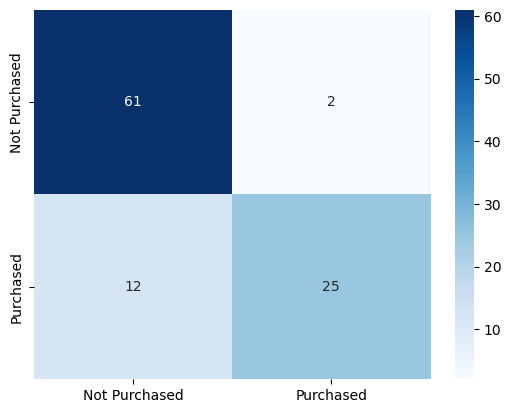

In [33]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'])

In [34]:
metrices = ['Accuracy' , 'error rate' , 'precision' , 'recall']
values = [accuracy , error_rate , precision , recall]

<BarContainer object of 4 artists>

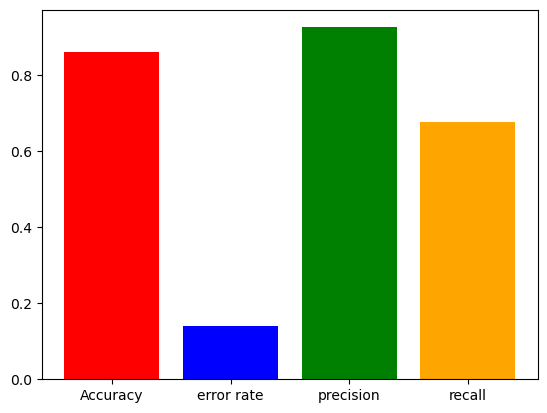

In [35]:
plt.bar(metrices , values , color=['red' , 'blue' , 'green' , 'orange'])